In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))


# فصل ۷ — ماشین‌های بردار پشتیبان (SVM)
## درس ۴: رگرسیون بردار پشتیبان (SVR)


در این درس با **رگرسیون بردار پشتیبان (SVR)** آشنا می‌شوید—نسخهٔ رگرسیونیِ SVM.

SVR یک روش **بیشینه‌سازی حاشیه (maximum-margin)** است: به‌جای کمینه‌کردن مستقیم خطای مربعی (مثل کمترین مربعات)، تابعی را می‌آموزد که **پیچیدگی کنترل‌شده** داشته باشد و یک لولهٔ تلورانسِ **$\epsilon$-ناحساس** پیرامون مقادیر هدف تعریف می‌کند.

این نوت‌بوک عمداً هم از نظر **ریاضی** و هم از نظر **عملی** پُرمایه است:

- مسئلهٔ بهینه‌سازی **پریمال** و **دوآل** SVR را استخراج می‌کنید.
- متغیرهای دوآل را تفسیر می‌کنید و می‌بینید چرا فقط بخشی از نمونه‌ها **بردار پشتیبان** می‌شوند.
- یاد می‌گیرید کرنل‌ها چگونه بدون ساختن صریحِ نگاشت ویژگی‌های بُعدبالا، **رگرسور غیرخطی** ایجاد می‌کنند.
- چند پایپلاین کامل در scikit-learn (پیش‌پردازش → مدل → تنظیم → ارزیابی) را روی **چند دیتاست رگرسیونی** از ریپوی شما اجرا می‌کنیم:
  - `house-prices.csv` (ترکیب عددی + دسته‌ای)
  - `cognitive.csv` (ترکیب عددی + yes/no)
  - `diamonds.csv` (دسته‌ای‌های پرتعداد؛ برای اجرا سریع‌تر نمونه‌برداری می‌کنیم)
  - `earthquake.csv` (ویژگی‌های جدولیِ مکانی-زمانی)
  - `salaries.csv` (دیتاست بسیار کوچک؛ ریسک واریانس و overfit را نشان می‌دهد)

**نکتهٔ عملی مهم:** کرنل-SVR با تعداد نمونه‌ها خوب مقیاس نمی‌شود (حافظه تقریباً $\mathcal{O}(n^2)$ و زمان معمولاً بین $\mathcal{O}(n^2)$ تا $\mathcal{O}(n^3)$).  
برای دیتاست‌های بزرگ معمولاً از **LinearSVR** یا **کرنل‌های تقریبی** استفاده می‌شود—در اینجا ایده را کوتاه مطرح می‌کنیم، اما تمرکز اصلی روی `sklearn.svm.SVR` است.

---


## ۱. اهداف یادگیری

در پایان این نوت‌بوک باید بتوانید:

1. **زیان $\epsilon$-ناحساس** را بنویسید و اثر آن را روی روباستی و sparsity توضیح دهید.
2. مسئلهٔ **پریمال SVR** را با متغیرهای اسلک بیان کنید و نقش $C$ و $\epsilon$ را توضیح دهید.
3. **دوآل** را استخراج کنید و ضرایب لاگرانژ $(\alpha_i, \alpha_i^*)$ را تفسیر کنید.
4. توضیح دهید چرا پیش‌بینی‌کننده به شکل (یک بسط محدود کرنلی)
   $$ f(x) = \sum_{i=1}^n (\alpha_i - \alpha_i^*)\,k(x_i,x) + b $$
   در می‌آید.
5. با استفاده از شرایط KKT توضیح دهید **کدام نقاط بردار پشتیبان می‌شوند**.
6. ابرپارامترهای $(C,\epsilon,\gamma)$ را تنظیم کنید و با MAE/RMSE/$R^2$ تحت CV ارزیابی کنید.
7. برای ویژگی‌های ترکیبی (عددی + دسته‌ای + ویژگی‌های ساده زمانی) پایپلاین robust بسازید و از leakage جلوگیری کنید.

---


## ۲. ایدهٔ اصلی: بیشینه‌سازی حاشیه برای رگرسیون

### ۲.۱ از توابع خطی تا ریسکِ منظم‌شده

یک پیش‌بین خطی را در نظر بگیرید:
$$ f(x) = w^\top x + b. $$

کمترین مربعات معمولی:
$$ \min_{w,b} \sum_{i=1}^n (y_i - (w^\top x_i + b))^2. $$

SVR از قالب **ریسک منظم‌شده** استفاده می‌کند:
$$ \min_{w,b}\;\frac{1}{2}\|w\|^2 + C \sum_{i=1}^n \ell(y_i, f(x_i)). $$

تفسیر:

- $\frac{1}{2}\|w\|^2$ ترم کنترل ظرفیت است (تابع صاف‌تر).
- $C>0$ مصالحهٔ برازش/همواری را تعیین می‌کند.
- $\ell$ زیان است.

چرا «حاشیه» در رگرسیون معنی دارد؟  
حتی با خروجی پیوسته، SVR تلاش می‌کند پیش‌بینی را **پایدار** نگه دارد (کوچک بودن $\|w\|$) و در عین حال خطاهای تا $\epsilon$ را بدون جریمه بپذیرد.

### ۲.۲ زیان $\epsilon$-ناحساس

زیان **$\epsilon$-ناحساس**:
$$
\ell_\epsilon(y, f(x)) =
\max\{0,\;|y - f(x)| - \epsilon\}.
$$

ویژگی‌ها:

1. **ناحیهٔ لوله**: اگر $|y-f(x)|\le \epsilon$ باشد، زیان صفر است.
2. **دُم‌های خطی**: اگر $|y-f(x)|>\epsilon$ باشد، جریمه خطی رشد می‌کند.
3. **روباستی**: دُم خطی معمولاً نسبت به squared loss حساسیت کمتری به outlier دارد.
4. **sparsity در دوآل**: معمولاً فقط نقاط روی/بیرون لوله وزن دوآل غیرصفر می‌گیرند.

فرم معادل با اسلک:

$$
\begin{aligned}
y_i - (w^\top x_i + b) &\le \epsilon + \xi_i,\\
(w^\top x_i + b) - y_i &\le \epsilon + \xi_i^*,\\
\xi_i,\xi_i^* &\ge 0.
\end{aligned}
$$

### ۲.۳ مسئلهٔ پریمال و تحدب

پریمال **$\epsilon$-SVR**:

$$
\begin{aligned}
\min_{w,b,\xi,\xi^*}\quad &
\frac{1}{2}\|w\|^2 + C\sum_{i=1}^n (\xi_i + \xi_i^*)\\
\text{s.t.}\quad &
y_i - (w^\top x_i + b) \le \epsilon + \xi_i,\quad i=1,\dots,n\\
&
(w^\top x_i + b) - y_i \le \epsilon + \xi_i^*,\quad i=1,\dots,n\\
&
\xi_i \ge 0,\;\xi_i^* \ge 0.
\end{aligned}
$$

این یک مسئلهٔ **محدب** است، بنابراین جواب بهینهٔ سراسری دارد و KKT ابزار قدرتمندی برای تحلیل است.

---

## ۳. دوآل، کرنل‌ها و شهود قضیهٔ representer

### ۳.۱ لاگرانژ و KKT (جزئی‌تر)

ضرایب:

- $\alpha_i \ge 0$ برای $y_i - f(x_i) \le \epsilon + \xi_i$،
- $\alpha_i^* \ge 0$ برای $f(x_i) - y_i \le \epsilon + \xi_i^*$،
- $\eta_i,\eta_i^* \ge 0$ برای $\xi_i,\xi_i^* \ge 0$.

لاگرانژ:

$$
\begin{aligned}
\mathcal{L} &=
\frac{1}{2}\|w\|^2 + C\sum_i(\xi_i+\xi_i^*) \\
&\quad + \sum_i \alpha_i\big(y_i - w^\top x_i - b - \epsilon - \xi_i\big)
+ \sum_i \alpha_i^*\big(w^\top x_i + b - y_i - \epsilon - \xi_i^*\big)
- \sum_i \eta_i \xi_i - \sum_i \eta_i^* \xi_i^*.
\end{aligned}
$$

شرایط KKT شامل:

**(الف) ایستایی**

- نسبت به $w$:
  $$ w = \sum_i (\alpha_i-\alpha_i^*)x_i. $$
- نسبت به $b$:
  $$ \sum_i (\alpha_i-\alpha_i^*) = 0. $$
- نسبت به $\xi$:
  $$ 0\le \alpha_i \le C,\qquad 0\le \alpha_i^* \le C. $$

**(ب) امکان‌پذیری پریمال**، **(ج) امکان‌پذیری دوآل**، و **(د) اسلک مکمل**:

$$
\alpha_i\big(y_i - f(x_i) - \epsilon - \xi_i\big)=0,\qquad
\alpha_i^*\big(f(x_i) - y_i - \epsilon - \xi_i^*\big)=0,
$$
$$
\eta_i \xi_i = 0,\qquad \eta_i^* \xi_i^* = 0.
$$

### ۳.۲ تابع هدف دوآل (کرنلی)

دوآل:

$$
\begin{aligned}
\max_{\alpha,\alpha^*}\quad &
-\frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n(\alpha_i-\alpha_i^*)(\alpha_j-\alpha_j^*)\langle x_i,x_j\rangle
- \epsilon\sum_{i=1}^n(\alpha_i+\alpha_i^*)
+ \sum_{i=1}^n y_i(\alpha_i-\alpha_i^*)\\
\text{s.t.}\quad &
\sum_{i=1}^n(\alpha_i-\alpha_i^*) = 0,\qquad
0 \le \alpha_i \le C,\quad 0 \le \alpha_i^* \le C.
\end{aligned}
$$

کرنل‌کردن با $K_{ij}=k(x_i,x_j)$ انجام می‌شود و پیش‌بینی:

$$
f(x) = \sum_{i=1}^n (\alpha_i - \alpha_i^*)\,k(x_i,x) + b.
$$

### ۳.۳ چرا جواب به صورت بسط کرنلی است؟

از ایستایی داریم:
$$
w = \sum_{i=1}^n (\alpha_i-\alpha_i^*) x_i.
$$

پس حتی در پریمال هم $w$ در span داده‌های آموزشی قرار می‌گیرد.  
در حالت کرنلی، به‌صورت ضمنی $\phi(x)$ را جایگزین می‌کنیم و ضرب داخلی را با $k$ حساب می‌کنیم.

---

## ۴. بردار پشتیبان در SVR یعنی چه؟

در SVR، بردارهای پشتیبان معمولاً **روی یا بیرون** لولهٔ $\epsilon$ قرار می‌گیرند:

1. **داخل لوله**: $|y_i-f(x_i)|<\epsilon$
   - معمولاً $\alpha_i=\alpha_i^*=0$.
2. **روی لوله**: $|y_i-f(x_i)|=\epsilon$
   - معمولاً $0<\alpha_i<C$ یا $0<\alpha_i^*<C$.
3. **بیرون لوله**: $|y_i-f(x_i)|>\epsilon$
   - معمولاً $\alpha_i=C$ یا $\alpha_i^*=C$.

### ۴.۱ محاسبهٔ $b$ با استفاده از KKT

اگر برای یک $i$ داشته باشیم $0<\alpha_i<C$ آنگاه:
$$ y_i - (w^\top x_i + b) = \epsilon \Rightarrow b = y_i - w^\top x_i - \epsilon. $$

و اگر $0<\alpha_i^*<C$:
$$ (w^\top x_i + b) - y_i = \epsilon \Rightarrow b = y_i - w^\top x_i + \epsilon. $$

در عمل $b$ را روی چندین بردار پشتیبان «آزاد» میانگین می‌گیرند.

---

## ۵. ابرپارامترها (نگاه دقیق‌تر)

### ۵.۱ نقش $C$

$C$ سقف ضرایب دوآل را تعیین می‌کند و در عمل میزان سخت‌گیری در برازش را تنظیم می‌کند.

### ۵.۲ نقش $\epsilon$

$\epsilon$ عرض لولهٔ «بدون جریمه» است و می‌تواند بیانگر تلورانس خطای قابل قبول یا سطح نویز برچسب‌ها باشد.

### ۵.۳ کرنل و پارامترهای آن

کرنل‌های رایج: خطی، چندجمله‌ای، RBF، و سیگموید.  
RBF اغلب برای داده‌های جدولی یک baseline قوی است ولی به scaling بسیار حساس است.

---

## ۶. قواعد عملی برای نوت‌بوک‌های واقعی

1. ویژگی‌های عددی را **scale** کنید.
2. ویژگی‌های دسته‌ای را one-hot کنید.
3. از `Pipeline` برای جلوگیری از leakage استفاده کنید.
4. با CV تنظیم کنید، نه با test.
5. همیشه یک baseline ساده را مقایسه کنید.

در بخش بعد، برای شهود بهتر زیان $\epsilon$-ناحساس را رسم می‌کنیم.

---


## ۷. شهود بصری: زیان $\epsilon$-ناحساس و لوله

اگر با وجود ریاضی، شهود بصری داشته باشید بهتر یاد می‌گیرید.

باقیمانده $r = y - \hat{y}$، سپس:

$$ \ell_\epsilon(r) = \max\{0, |r| - \epsilon\}. $$

- اگر $|r|\le \epsilon$ باشد، زیان صفر است.
- اگر $|r|>\epsilon$ باشد، زیان خطی رشد می‌کند.

نمودار زیان را برای چند مقدار $\epsilon$ رسم می‌کنیم.

---


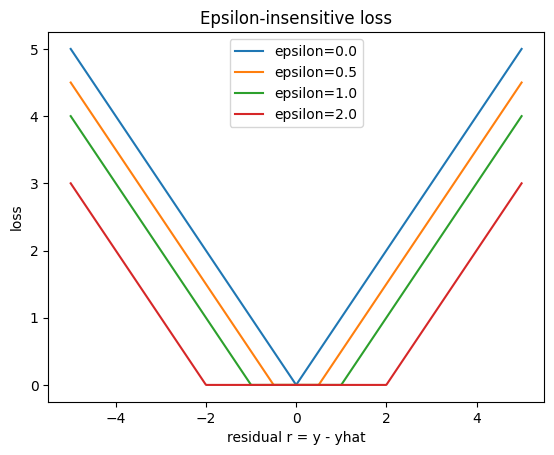

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def eps_insensitive_loss(residual, eps):
    return np.maximum(0.0, np.abs(residual) - eps)

r = np.linspace(-5, 5, 1000)

plt.figure()
for eps in [0.0, 0.5, 1.0, 2.0]:
    plt.plot(r, eps_insensitive_loss(r, eps), label=f"epsilon={eps}")
plt.title("Epsilon-insensitive loss")
plt.xlabel("residual r = y - yhat")
plt.ylabel("loss")
plt.legend()
plt.show()


In [3]:
# Core scientific stack
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression

# Optional interpretability helper (works for many estimators)
try:
    from sklearn.inspection import PartialDependenceDisplay
    HAS_PDP = True
except Exception:
    HAS_PDP = False

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def summarize_regression(y_true, y_pred, label="Model"):
    print(f"=== {label} ===")
    print(f"MAE  : {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"RMSE : {rmse(y_true, y_pred):.4f}")
    print(f"R^2  : {r2_score(y_true, y_pred):.4f}")


## ۸. توابع کمکی برای دسترسی به داده‌ها (مسیرهای نسبی)

دیتاست‌های شما در ریپو زیر این مسیرها قرار دارند:

- `../../../Datasets/Regression/...`
- `../../../Datasets/Classification/...`
- `../../../Datasets/Clustering/...`

چون این درس رگرسیون است، از **چند دیتاست رگرسیونی** استفاده می‌کنیم.  
اگر نوت‌بوک را در ساختار درست ریپو اجرا کنید، مسیرها باید مستقیم کار کنند.

---


In [4]:
from pathlib import Path

def load_csv(rel_path):
    p = Path(rel_path)
    if not p.exists():
        raise FileNotFoundError(
            f"Could not find {p}. Make sure you run this notebook from the expected repo structure."
        )
    return pd.read_csv(p)

# Five regression datasets (chosen to demonstrate different preprocessing needs)
PATH_HOUSE = "../../../Datasets/Regression/house-prices.csv"
PATH_COGNITIVE = "../../../Datasets/Regression/cognitive.csv"
PATH_DIAMONDS = "../../../Datasets/Regression/diamonds.csv"
PATH_EARTHQUAKE = "../../../Datasets/Regression/earthquake.csv"
PATH_SALARIES = "../../../Datasets/Regression/salaries.csv"

df_house = load_csv(PATH_HOUSE)
df_cog = load_csv(PATH_COGNITIVE)
df_diamonds = load_csv(PATH_DIAMONDS)
df_quake = load_csv(PATH_EARTHQUAKE)
df_salary = load_csv(PATH_SALARIES)

print("house-prices:", df_house.shape); display(df_house.head())
print("\ncognitive:", df_cog.shape); display(df_cog.head())
print("\ndiamonds:", df_diamonds.shape); display(df_diamonds.head())
print("\nearthquake:", df_quake.shape); display(df_quake.head())
print("\nsalaries:", df_salary.shape); display(df_salary.head())


house-prices: (128, 8)


,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East



cognitive: (434, 5)


,kid_score,mom_hs,mom_iq,mom_work,mom_age
0,65,yes,121.117529,yes,27
1,98,yes,89.361882,yes,25
2,85,yes,115.443165,yes,27
3,83,yes,99.449639,yes,25
4,115,yes,92.745710,yes,27



diamonds: (53940, 11)


,id,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



earthquake: (87372, 6)


,date,time,latitude,longitude,depth,magnitude
0,2008-11-01,00:31:25,-0.60,98.89553,20.0,2.99
1,2008-11-01,01:34:29,-6.61,129.38722,30.1,5.51
2,2008-11-01,01:38:14,-3.65,127.99068,5.0,3.54
3,2008-11-01,02:20:05,-4.20,128.09700,5.0,2.42
4,2008-11-01,02:32:18,-4.09,128.20047,10.0,2.41



salaries: (1000, 4)


,Name,Age,Job,Salary
0,Kevin Sanders,24,Software Engineer,7300
1,Lisa Mills,26,High School Teacher,6100
2,Donna Allison,27,Dentist,12700
3,Michael Schmitt,43,Dentist,17500
4,Lisa Shaffer,31,Accountant,7400


## ۹. مثال ۱ — قیمت خانه (ویژگی‌های ترکیبی)

دیتاست: `house-prices.csv`  
هدف: `Price`  
ویژگی‌ها شامل ستون‌های عددی (`SqFt`, `Bedrooms`, `Bathrooms`, `Offers`) و دسته‌ای (`Brick`, `Neighborhood`) هستند.

مراحل:

1. ساخت پایپلاین پیش‌پردازش ضد-leakage،
2. آموزش baseline **LinearRegression**،
3. آموزش SVR با چند کرنل،
4. تنظیم RBF-SVR با GridSearchCV،
5. بررسی residual و learning curve،
6. (اختیاری) رسم partial dependence برای یک ویژگی عددی.

---


Numeric: ['Home', 'SqFt', 'Bedrooms', 'Bathrooms', 'Offers']
Categorical: ['Brick', 'Neighborhood']
=== LinearRegression baseline ===
MAE  : 8338.0040
RMSE : 10277.3255
R^2  : 0.8277
=== SVR (linear) ===
MAE  : 19683.5965
RMSE : 23892.0131
R^2  : 0.0688
=== SVR (poly, initial) ===
MAE  : 19921.1386
RMSE : 24170.2532
R^2  : 0.0470
=== SVR (RBF, initial) ===
MAE  : 20265.1007
RMSE : 24522.4883
R^2  : 0.0190


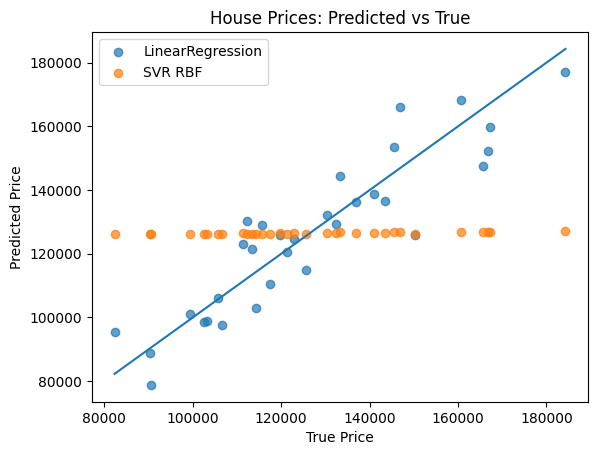

In [5]:
# Split features/target
target = "Price"
X = df_house.drop(columns=[target])
y = df_house[target].astype(float)

# Identify column types
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

# Preprocessing for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop",
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

# Baseline: linear regression
lin_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("reg", LinearRegression())
])

lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
summarize_regression(y_test, y_pred_lin, label="LinearRegression baseline")

# SVR models: linear, polynomial, and RBF (initial guesses)
svr_linear = Pipeline(steps=[
    ("preprocess", preprocess),
    ("svr", SVR(kernel="linear", C=10.0, epsilon=0.1))
])

svr_poly = Pipeline(steps=[
    ("preprocess", preprocess),
    ("svr", SVR(kernel="poly", C=10.0, epsilon=0.1, degree=3, gamma="scale", coef0=1.0))
])

svr_rbf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("svr", SVR(kernel="rbf", C=50.0, epsilon=0.1, gamma="scale"))
])

for model, name in [(svr_linear,"SVR (linear)"), (svr_poly,"SVR (poly, initial)"), (svr_rbf,"SVR (RBF, initial)")]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    summarize_regression(y_test, pred, label=name)

# Plot predictions vs truth (baseline vs RBF)
plt.figure()
plt.scatter(y_test, y_pred_lin, alpha=0.7, label="LinearRegression")
plt.scatter(y_test, svr_rbf.predict(X_test), alpha=0.7, label="SVR RBF")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("House Prices: Predicted vs True")
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()


### ۹.۱ تنظیم ابرپارامتر با GridSearchCV

پارامترهای تنظیم:

- $C \in \{1,10,100,300\}$
- $\epsilon \in \{0.05,0.1,0.2\}$
- $\gamma \in \{\text{"scale"}, 0.1, 0.01, 0.001\}$ (کرنل RBF)

از KFold برای CV استفاده می‌کنیم.  
برای گزارش جدی، test را جدا نگه دارید و تنظیم را فقط روی train با CV انجام دهید.

---


In [6]:
param_grid = {
    "svr__C": [1.0, 10.0, 100.0, 300.0],
    "svr__epsilon": [0.05, 0.1, 0.2],
    "svr__gamma": ["scale", 0.1, 0.01, 0.001],
}

svr_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("svr", SVR(kernel="rbf"))
])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gs = GridSearchCV(
    svr_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Best CV RMSE:", -gs.best_score_)

best_model = gs.best_estimator_
y_pred_best = best_model.predict(X_test)
summarize_regression(y_test, y_pred_best, label="SVR (RBF, tuned)")

# Count support vectors
svr_step = best_model.named_steps["svr"]
print("Number of support vectors:", svr_step.support_.shape[0])


Best params: {'svr__C': 300.0, 'svr__epsilon': 0.2, 'svr__gamma': 0.1}
Best CV RMSE: 26563.390881542233
=== SVR (RBF, tuned) ===
MAE  : 19066.2348
RMSE : 23212.3192
R^2  : 0.1210
Number of support vectors: 96


### ۹.۲ تحلیل باقیمانده‌ها

باقیمانده‌ها برای تشخیص موارد زیر مفیدند:

- بایاس سیستماتیک،
- ناهمسان‌واریانسی،
- outlier.

باقیماندهٔ نمونهٔ $i$:
$$ r_i = y_i - \hat{y}_i. $$

---


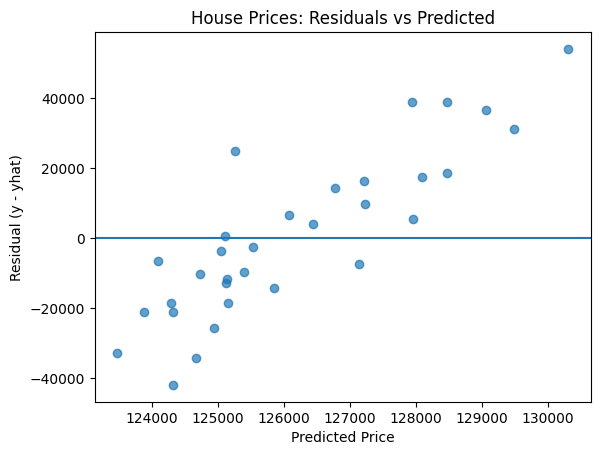

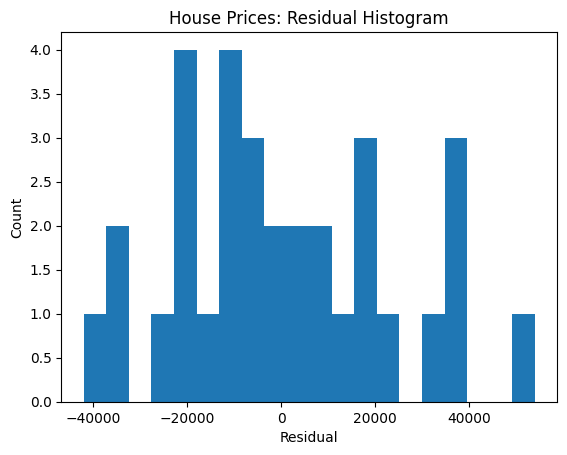

In [7]:
res = y_test.values - y_pred_best
plt.figure()
plt.scatter(y_pred_best, res, alpha=0.7)
plt.axhline(0)
plt.title("House Prices: Residuals vs Predicted")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (y - yhat)")
plt.show()

plt.figure()
plt.hist(res, bins=20)
plt.title("House Prices: Residual Histogram")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()


### ۹.۳ منحنی یادگیری

- اگر RMSE آموزش کم و RMSE CV زیاد باشد: احتمال overfit.
- اگر هر دو زیاد باشند: احتمال underfit.
- اگر با داده بیشتر بهتر شوند: داده بیشتر کمک می‌کند.

---


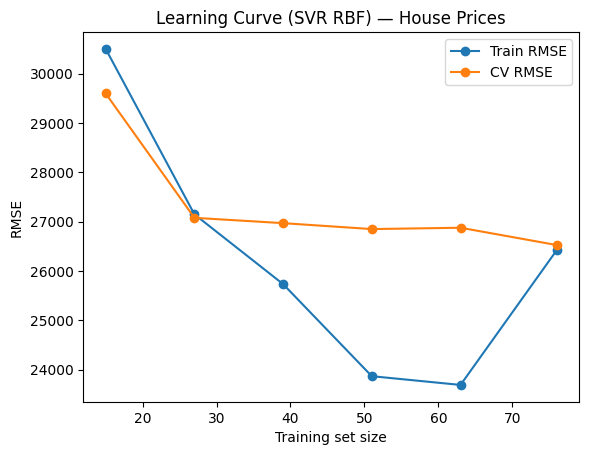

In [8]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_rmse, marker="o", label="Train RMSE")
plt.plot(train_sizes, val_rmse, marker="o", label="CV RMSE")
plt.title("Learning Curve (SVR RBF) — House Prices")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.legend()
plt.show()


### ۹.۴ (اختیاری) Partial dependence برای یک ویژگی عددی

Partial dependence روشی نسبتاً مدل-ناوابسته برای دیدن اثر یک ویژگی روی پیش‌بینی (میانگین‌گیری روی سایر ویژگی‌ها) است.

برای SVR کرنلی، این «توضیح داخلی» نیست، اما یک sanity check مفید است.

اگر `sklearn.inspection` موجود باشد، برای `SqFt` رسم می‌کنیم.

---


<Figure size 640x480 with 0 Axes>

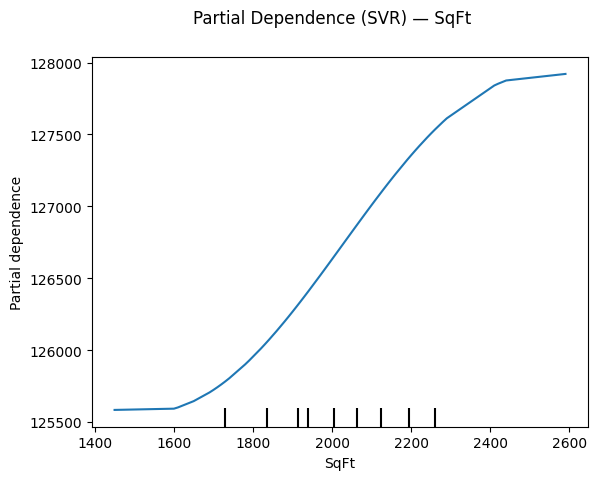

In [9]:
if HAS_PDP and "SqFt" in X.columns:
    plt.figure()
    PartialDependenceDisplay.from_estimator(
        best_model, X_train, features=["SqFt"]
    )
    plt.suptitle("Partial Dependence (SVR) — SqFt")
    plt.show()
else:
    print("Partial dependence plot not available (missing module) or feature not present.")


## ۱۰. مثال ۲ — cognitive (kid_score): حساسیت به scaling

دیتاست: `cognitive.csv`  
هدف: `kid_score`  
ویژگی‌های دسته‌ای: `mom_hs`, `mom_work` (yes/no)

در اینجا نشان می‌دهیم SVR نسبت به scale حساس است و scaling درست معمولاً تفاوت ایجاد می‌کند.

---


=== SVR (scaled) ===
MAE  : 14.6366
RMSE : 18.1911
R^2  : 0.2517
=== SVR (no scaling) ===
MAE  : 14.8594
RMSE : 18.6615
R^2  : 0.2125


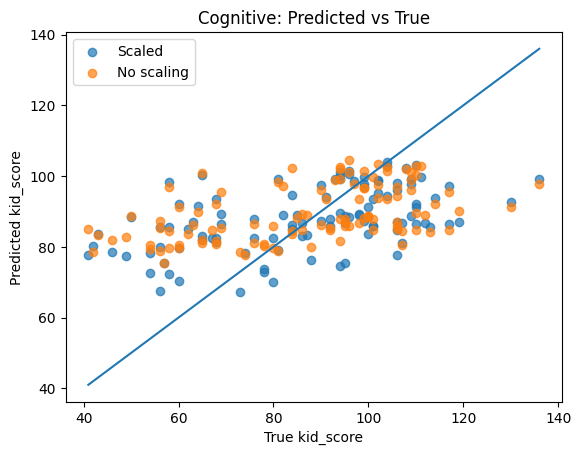

In [10]:
target = "kid_score"
X = df_cog.drop(columns=[target])
y = df_cog[target].astype(float)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_transformer_noscale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

preprocess_noscale = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_noscale, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

svr_scaled = Pipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("svr", SVR(kernel="rbf", C=10.0, epsilon=1.0, gamma="scale"))
])

svr_noscale = Pipeline(steps=[
    ("preprocess", preprocess_noscale),
    ("svr", SVR(kernel="rbf", C=10.0, epsilon=1.0, gamma="scale"))
])

svr_scaled.fit(X_train, y_train)
svr_noscale.fit(X_train, y_train)

pred_scaled = svr_scaled.predict(X_test)
pred_noscale = svr_noscale.predict(X_test)

summarize_regression(y_test, pred_scaled, label="SVR (scaled)")
summarize_regression(y_test, pred_noscale, label="SVR (no scaling)")

plt.figure()
plt.scatter(y_test, pred_scaled, alpha=0.7, label="Scaled")
plt.scatter(y_test, pred_noscale, alpha=0.7, label="No scaling")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Cognitive: Predicted vs True")
plt.xlabel("True kid_score")
plt.ylabel("Predicted kid_score")
plt.legend()
plt.show()


### ۱۰.۱ بازه اطمینان bootstrap برای RMSE (تخمین سریع عدم‌قطعیت)

یک RMSE روی تست فقط یک تخمین نقطه‌ای است.  
برای یک تخمین سریع عدم‌قطعیت، bootstrap می‌کنیم:

1. نمونه‌گیری با جایگذاری از تست،
2. محاسبه RMSE برای هر نمونه،
3. گرفتن صدک‌ها (مثلاً 2.5% و 97.5%).

این جایگزین تحلیل آماری دقیق نیست، ولی یک sanity check خوب است.

---


In [11]:
# Bootstrap RMSE for the scaled cognitive SVR
rng = np.random.RandomState(RANDOM_STATE)

B = 500
y_true = np.asarray(y_test)
y_pred = np.asarray(pred_scaled)

rmses = []
n = len(y_true)
for _ in range(B):
    idx = rng.randint(0, n, size=n)
    rmses.append(rmse(y_true[idx], y_pred[idx]))

lo, hi = np.percentile(rmses, [2.5, 97.5])
print(f"Bootstrap 95% CI for RMSE: [{lo:.3f}, {hi:.3f}]")


Bootstrap 95% CI for RMSE: [15.890, 20.274]


## ۱۱. مثال ۳ — Diamonds (نمونه‌برداری‌شده): دسته‌ای زیاد + هزینهٔ کرنل

دیتاست: `diamonds.csv`  
هدف: `price`

برای قابل اجرا بودن، دیتاست را نمونه‌برداری می‌کنیم و سپس SVR را آموزش می‌دهیم و تعداد بردارهای پشتیبان را بررسی می‌کنیم.

---


=== SVR (RBF) — Diamonds (subsampled) ===
MAE  : 557.0824
RMSE : 1161.8442
R^2  : 0.9119
Support vectors: 2649 out of 3200


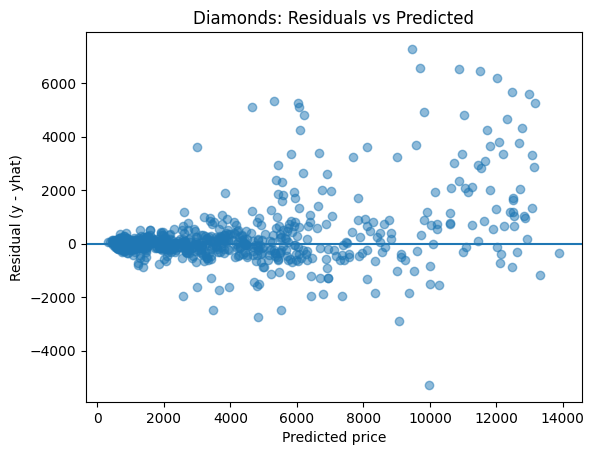

In [12]:
# Keep a reproducible subsample
df = df_diamonds.copy()

# Some versions of this dataset have an "id" column; drop it if present
if "id" in df.columns:
    df = df.drop(columns=["id"])

# Remove rows with missing target
df = df.dropna(subset=["price"])

# Subsample (adjust n if you have more compute)
n = min(4000, len(df))
df = df.sample(n=n, random_state=RANDOM_STATE)

target = "price"
X = df.drop(columns=[target])
y = df[target].astype(float)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

svr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("svr", SVR(kernel="rbf", C=200.0, epsilon=50.0, gamma="scale"))
])

svr.fit(X_train, y_train)
pred = svr.predict(X_test)
summarize_regression(y_test, pred, label="SVR (RBF) — Diamonds (subsampled)")

svr_step = svr.named_steps["svr"]
print("Support vectors:", svr_step.support_.shape[0], "out of", X_train.shape[0])

# Visual: residuals
res = y_test.values - pred
plt.figure()
plt.scatter(pred, res, alpha=0.5)
plt.axhline(0)
plt.title("Diamonds: Residuals vs Predicted")
plt.xlabel("Predicted price")
plt.ylabel("Residual (y - yhat)")
plt.show()


## ۱۲. آزمایش کنترل‌شده: $C$ و $\epsilon$ در برابر تعداد بردارهای پشتیبان

یک sweep کوچک روی `house-prices.csv` انجام می‌دهیم و:

- RMSE را برحسب $\epsilon$ (برای چند $C$) رسم می‌کنیم،
- تعداد بردارهای پشتیبان را برحسب $\epsilon$ رسم می‌کنیم.

---


,C,epsilon,rmse,n_support
0,1.0,0.05,24756.252171,96
1,1.0,0.10,24756.252171,96
2,1.0,0.20,24756.252171,96
3,1.0,0.50,24756.252171,96
4,1.0,1.00,24756.252171,96
5,10.0,0.05,24713.243580,96
6,10.0,0.10,24713.243580,96
7,10.0,0.20,24713.243580,96
8,10.0,0.50,24713.243580,96
9,10.0,1.00,24713.243580,96


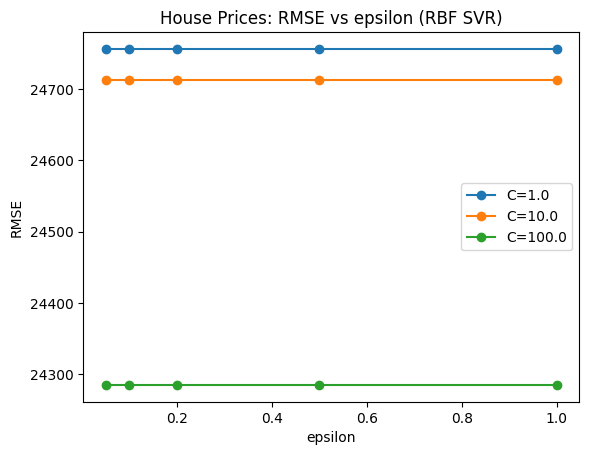

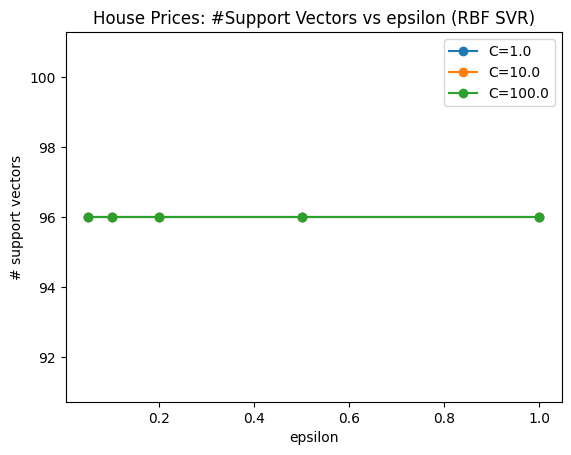

In [13]:
# Reuse the house dataset (recompute quickly for self-containment)
df = df_house.copy()
target = "Price"
X = df.drop(columns=[target])
y = df[target].astype(float)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

Cs = [1.0, 10.0, 100.0]
epsilons = [0.05, 0.1, 0.2, 0.5, 1.0]

results = []
for C in Cs:
    for eps in epsilons:
        model = Pipeline(steps=[
            ("preprocess", preprocess),
            ("svr", SVR(kernel="rbf", C=C, epsilon=eps, gamma="scale"))
        ])
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        svr_step = model.named_steps["svr"]
        results.append({
            "C": C,
            "epsilon": eps,
            "rmse": rmse(y_test, pred),
            "n_support": svr_step.support_.shape[0]
        })

res_df = pd.DataFrame(results)
display(res_df)

plt.figure()
for C in Cs:
    d = res_df[res_df["C"] == C].sort_values("epsilon")
    plt.plot(d["epsilon"], d["rmse"], marker="o", label=f"C={C}")
plt.title("House Prices: RMSE vs epsilon (RBF SVR)")
plt.xlabel("epsilon")
plt.ylabel("RMSE")
plt.legend()
plt.show()

plt.figure()
for C in Cs:
    d = res_df[res_df["C"] == C].sort_values("epsilon")
    plt.plot(d["epsilon"], d["n_support"], marker="o", label=f"C={C}")
plt.title("House Prices: #Support Vectors vs epsilon (RBF SVR)")
plt.xlabel("epsilon")
plt.ylabel("# support vectors")
plt.legend()
plt.show()


## ۱۳. مثال ۴ — بزرگی زلزله (ویژگی‌سازی ساده)

دیتاست: `earthquake.csv`  
هدف: `magnitude`

کارهایی که انجام می‌دهیم:

1. تبدیل `date` و `time` به timestamp،
2. استخراج ویژگی‌های زمانی ساده (year, month, day, hour)،
3. آموزش SVR (RBF)،
4. مقایسه با baseline خطی.

این مثال یادآوری می‌کند که «کرنل» جایگزین ویژگی‌سازی خوب نیست؛ ویژگی‌های خوب همچنان مهم‌اند.

---


=== Earthquake: LinearRegression ===
MAE  : 0.5975
RMSE : 0.7444
R^2  : 0.1289
=== Earthquake: SVR (RBF) ===
MAE  : 0.5019
RMSE : 0.6503
R^2  : 0.3351


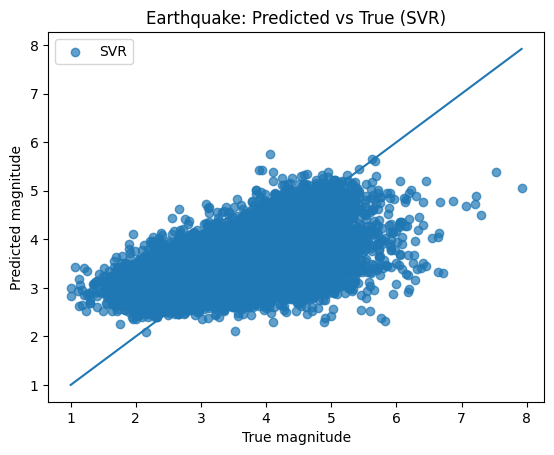

In [14]:
df = df_quake.copy()

# Basic parsing
df["timestamp"] = pd.to_datetime(df["date"].astype(str) + " " + df["time"].astype(str), errors="coerce")
df = df.dropna(subset=["timestamp", "magnitude"])

# Simple time features
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day
df["hour"] = df["timestamp"].dt.hour

target = "magnitude"
feature_cols = ["latitude", "longitude", "depth", "year", "month", "day", "hour"]
X = df[feature_cols]
y = df[target].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

# Pipelines (numeric only here)
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

lin = Pipeline(steps=[
    ("preprocess", preprocess),
    ("reg", LinearRegression())
])

svr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("svr", SVR(kernel="rbf", C=10.0, epsilon=0.05, gamma="scale"))
])

lin.fit(X_train, y_train)
svr.fit(X_train, y_train)

pred_lin = lin.predict(X_test)
pred_svr = svr.predict(X_test)

summarize_regression(y_test, pred_lin, label="Earthquake: LinearRegression")
summarize_regression(y_test, pred_svr, label="Earthquake: SVR (RBF)")

plt.figure()
plt.scatter(y_test, pred_svr, alpha=0.7, label="SVR")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Earthquake: Predicted vs True (SVR)")
plt.xlabel("True magnitude")
plt.ylabel("Predicted magnitude")
plt.legend()
plt.show()


## ۱۴. مثال ۵ — Salaries (دیتاست خیلی کوچک): ریسک واریانس و overfit

دیتاست: `salaries.csv`  
هدف: `Salary`

این دیتاست بسیار کوچک است؛ بنابراین:

- CV می‌تواند واریانس زیادی داشته باشد،
- ویژگی‌های شناسه‌ای مثل `Name` معمولاً نویز هستند،
- مدل‌های پیچیده ممکن است overfit شوند.

---


In [15]:
df = df_salary.copy()

target = "Salary"
# Drop "Name" by default; it is often a pure identifier (high-cardinality noise)
X = df.drop(columns=[target, "Name"])
y = df[target].astype(float)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_cols),
    ]
)

# Because the dataset is tiny, a single split is unstable; we use CV scores
svr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("svr", SVR(kernel="rbf", C=100.0, epsilon=100.0, gamma="scale"))
])

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Manual CV evaluation (RMSE)
rmses = []
for train_idx, test_idx in cv.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    svr.fit(X_tr, y_tr)
    pred = svr.predict(X_te)
    rmses.append(rmse(y_te, pred))

print("CV RMSEs:", rmses)
print("Mean CV RMSE:", float(np.mean(rmses)))


CV RMSEs: [np.float64(1206.891012798138), np.float64(1282.8170424677821), np.float64(1261.82587831403)]
Mean CV RMSE: 1250.5113111933167


## ۱۵. ایده‌های مقیاس‌پذیری: کرنل‌های تقریبی (مفهومی + کد کوتاه)

برای $n$ بزرگ، kernel-SVR گران است. یک ایده رایج تقریب RBF با ویژگی‌های تصادفی است:

- `RBFSampler` ویژگی‌هایی می‌سازد که $\phi(x)^\top\phi(x') \approx k_{\text{RBF}}(x,x')$.
- سپس یک مدل خطی روی این ویژگی‌ها آموزش می‌دهیم.

این بخش پلی به مباحث مقیاس‌پذیری (مثلاً فصل ۳۵) است.

---


In [16]:
# Optional: approximate RBF kernel with random Fourier features
try:
    from sklearn.kernel_approximation import RBFSampler
    from sklearn.linear_model import Ridge

    # Use the house-prices dataset as an example
    df = df_house.copy()
    target = "Price"
    X = df.drop(columns=[target])
    y = df[target].astype(float)

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric_cols),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), categorical_cols),
        ]
    )

    # Random Fourier features + linear ridge regression
    rbf_features = RBFSampler(gamma=0.01, n_components=500, random_state=RANDOM_STATE)

    approx_model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("rbf", rbf_features),
        ("reg", Ridge(alpha=1.0))
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE
    )

    approx_model.fit(X_train, y_train)
    pred = approx_model.predict(X_test)
    summarize_regression(y_test, pred, label="Approx RBF (RBFSampler) + Ridge")

except Exception as e:
    print("Approx-kernel section skipped (missing dependency):", repr(e))


=== Approx RBF (RBFSampler) + Ridge ===
MAE  : 9946.5938
RMSE : 12342.4820
R^2  : 0.7515


## ۱۶. (اختیاری) حل‌گر کوچک دوآل SVR «از صفر» (آموزشی)

همان بخش آموزشیِ حل QP برای اتصال مستقیم ریاضی به پیاده‌سازی.

اگر `cvxopt` نصب نباشد، این بخش رد می‌شود.

---


In [17]:
# Educational QP: attempt tiny dual SVR with cvxopt (if available)
import numpy as np

def rbf_kernel(X, gamma):
    # X: (n,d)
    sq = np.sum(X**2, axis=1, keepdims=True)
    dist2 = sq - 2*X@X.T + sq.T
    return np.exp(-gamma * dist2)

try:
    from cvxopt import matrix, solvers
    solvers.options["show_progress"] = False

    # Tiny synthetic dataset
    rng = np.random.RandomState(RANDOM_STATE)
    n = 20
    Xs = rng.uniform(-2, 2, size=(n, 1))
    ys = np.sin(Xs[:, 0]) + 0.1*rng.randn(n)

    C = 10.0
    epsilon = 0.1
    gamma = 1.0

    K = rbf_kernel(Xs, gamma=gamma)

    # Variables: z = [alpha; alpha*] in R^{2n}
    P = np.block([[K, -K],
                  [-K, K]])
    q = np.hstack([epsilon*np.ones(n) - ys, epsilon*np.ones(n) + ys])

    A = np.hstack([np.ones(n), -np.ones(n)])[None, :]
    b = np.array([0.0])

    G = np.vstack([
        -np.eye(2*n),
        np.eye(2*n)
    ])
    h = np.hstack([
        np.zeros(2*n),
        C*np.ones(2*n)
    ])

    sol = solvers.qp(matrix(P), matrix(q), matrix(G), matrix(h), matrix(A), matrix(b))
    z = np.array(sol["x"]).reshape(-1)
    alpha = z[:n]
    alpha_star = z[n:]
    coef = alpha - alpha_star

    tol = 1e-6
    idx = np.where(((alpha > tol) & (alpha < C-tol)) | ((alpha_star > tol) & (alpha_star < C-tol)))[0]
    if len(idx) == 0:
        idx = [int(np.argmax(np.abs(coef)))]
    i0 = idx[0]
    b0 = ys[i0] - np.sum(coef * K[i0, :])
    print("Non-zero dual coeffs:", int(np.sum(np.abs(coef) > 1e-6)), "out of", n)

    xg = np.linspace(-2, 2, 200)[:, None]
    Kg = np.exp(-gamma * (xg**2 - 2*xg@Xs.T + (Xs.T)**2))
    yhat = Kg @ coef + b0

    plt.figure()
    plt.scatter(Xs[:, 0], ys, label="data")
    plt.plot(xg[:, 0], yhat, label="SVR from dual QP")
    plt.title("Tiny SVR solved via QP (educational)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

except Exception as e:
    print("cvxopt is not available (or QP failed). Skipping from-scratch section.")
    print("Reason:", repr(e))


cvxopt is not available (or QP failed). Skipping from-scratch section.
Reason: ModuleNotFoundError("No module named 'cvxopt'")


## ۱۷. جمع‌بندی

- SVR یک مسئلهٔ محدب است که همواری و نقض لوله را موازنه می‌کند.
- زیان $\epsilon$-ناحساس خطاهای کوچک را نادیده می‌گیرد.
- پیش‌بینی به صورت بسط کرنلی روی بردارهای پشتیبان است.
- scaling برای SVR ضروری است.
- برای داده‌های ترکیبی از `ColumnTransformer` و `Pipeline` استفاده کنید.
- برای $n$ بزرگ به تقریبات کرنل فکر کنید.

---

## ۱۸. تمرین‌ها

1. روی `cognitive.csv` مقدار $\epsilon$ را sweep کنید و RMSE را رسم کنید.
2. روی `house-prices.csv` کرنل‌های `linear`، `rbf`، `poly` را مقایسه کنید.
3. یک مثال leakage بسازید (scaling روی کل داده) و اختلاف نمره‌ها را ببینید.
4. به برچسب‌ها outlier اضافه کنید و اثر را مقایسه کنید.
5. `n_components` در `RBFSampler` را تغییر دهید و trade-off را بررسی کنید.

---
